In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Adjust sep='\t' if tab-separated, sep=',' if comma-separated
df1 = pd.read_csv("/content/CFB-GBM_clinical_data_v02_20260129.tsv", sep='\t')  # Table 1
df2 = pd.read_csv("/content/CFB-GBM_treatment_data_v02_20260129.tsv", sep='\t')  # Table 2

merged_df = pd.merge(df1, df2, on='id_patient', how='inner')

# Specify the exact column order
final_columns = [
    'id_patient',  # common ID
    'survival (weeks)',
    'age_at_t0 (years)',
    'who_performance_status',
    'gender',
    'height (cm)',
    'weight (kg)',
    'delay_t0_to_radiotherapy (weeks)',
    'dose (Gy)',
    'fractions_number'
]

# Reorder the merged dataframe
merged_df = merged_df[final_columns]

# Save as Excel
#excel_filename = 'final_table.xlsx'
#merged_df.to_excel(excel_filename, index=False)

# Download the Excel file
#files.download(excel_filename)

In [ ]:
df = merged_df

In [ ]:
df.head()

,id_patient,survival (weeks),age_at_t0 (years),who_performance_status,gender,height (cm),weight (kg),delay_t0_to_radiotherapy (weeks),dose (Gy),fractions_number
0,1,30,75,0.0,F,152,49.0,1.0,40.05,15.0
1,2,43,75,2.0,M,177,86.0,3.0,60.00,30.0
2,3,29,75,2.0,F,165,75.0,0.0,40.05,15.0
3,4,40,70,1.0,M,180,74.0,1.0,60.00,30.0
4,5,70,70,1.0,F,164,69.0,1.0,60.00,30.0


In [ ]:
print(df['survival (weeks)'])

0       30
1       43
2       29
3       40
4       70
      ... 
259     45
260    104
261     34
262     41
263     56
Name: survival (weeks), Length: 264, dtype: int64


In [ ]:
max_week = df['survival (weeks)'].max()
max_week

238

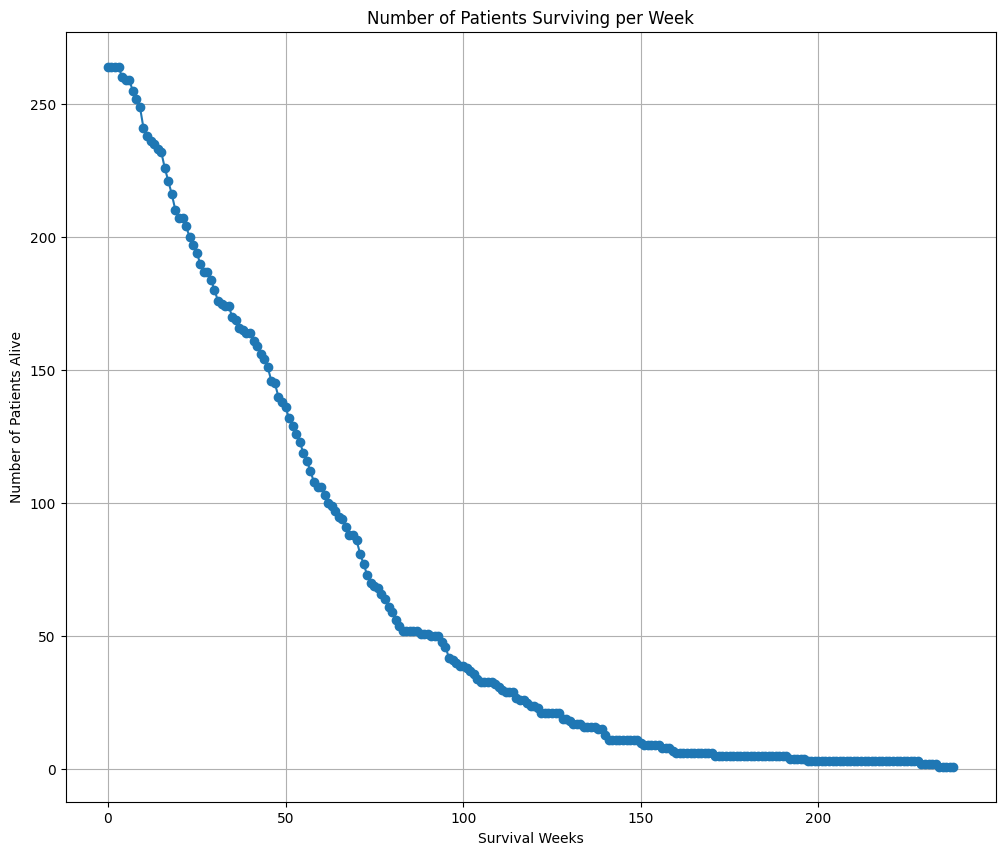

In [ ]:
weeks = list(range(0, max_week + 1))
patients_alive = []

for i in weeks:
    alive_count = (df['survival (weeks)'] >= i).sum()
    patients_alive.append(alive_count)

# Step 5: Plot the survival curve
plt.figure(figsize=(12,10))
plt.plot(weeks, patients_alive, marker='o')
plt.title('Number of Patients Surviving per Week')
plt.xlabel('Survival Weeks')
plt.ylabel('Number of Patients Alive')
plt.grid(True)
plt.show()

In [ ]:
survival_table = pd.DataFrame({
    'Week': weeks,
    'Patients_Alive': patients_alive
})

survival_table.to_csv('weekly_survival_table.csv', index=False)
survival_table

,Week,Patients_Alive
0,0,264
1,1,264
2,2,264
3,3,264
4,4,260
...,...,...
234,234,1
235,235,1
236,236,1
237,237,1


In [ ]:
# Total patients at week 0
total_patients = survival_table['Patients_Alive'].iloc[0]

# Add a new column: Survival Probability
survival_table['Survival_Probability'] = survival_table['Patients_Alive'] / total_patients

# Show first few rows
survival_table

,Week,Patients_Alive,Survival_Probability
0,0,264,1.000000
1,1,264,1.000000
2,2,264,1.000000
3,3,264,1.000000
4,4,260,0.984848
...,...,...,...
234,234,1,0.003788
235,235,1,0.003788
236,236,1,0.003788
237,237,1,0.003788


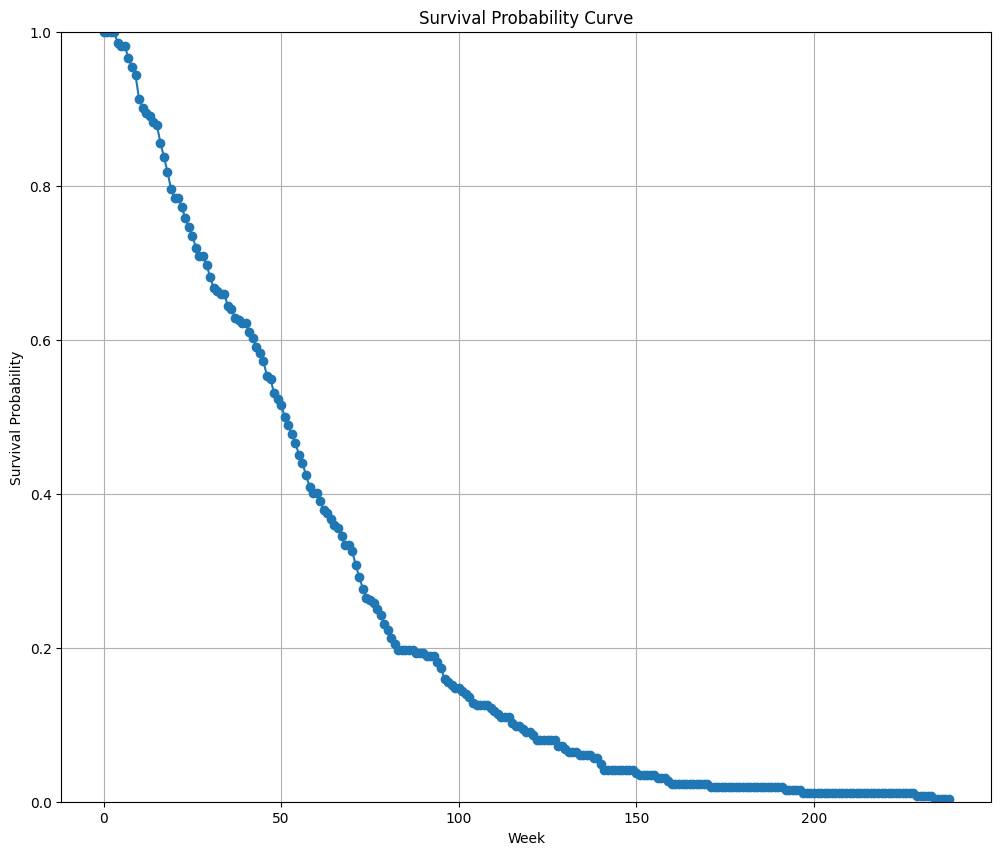

In [ ]:
plt.figure(figsize=(12,10))
plt.plot(survival_table['Week'], survival_table['Survival_Probability'], marker='o')
plt.title('Survival Probability Curve')
plt.xlabel('Week')
plt.ylabel('Survival Probability')
plt.ylim(0,1)
plt.grid(True)
plt.show()

In [ ]:
survival_table['Weekly_Deaths'] = survival_table['Patients_Alive'].diff(-1).fillna(0)
#survival_table['Weekly_Deaths'] = survival_table['Weekly_Deaths'].astype(int)
survival_table

,Week,Patients_Alive,Survival_Probability,Weekly_Deaths
0,0,264,1.000000,0.0
1,1,264,1.000000,0.0
2,2,264,1.000000,0.0
3,3,264,1.000000,4.0
4,4,260,0.984848,1.0
...,...,...,...,...
234,234,1,0.003788,0.0
235,235,1,0.003788,0.0
236,236,1,0.003788,0.0
237,237,1,0.003788,0.0


In [ ]:
male_patients_df = df[df['gender']=='M']
female_patients_df = df[df['gender']=='F']

# Calculate survival counts for males
male_alive_counts = []
for i in weeks:
    alive_male_count = (male_patients_df['survival (weeks)'] >= i).sum()
    male_alive_counts.append(alive_male_count)

# Calculate survival counts for females
female_alive_counts = []
for i in weeks:
    alive_female_count = (female_patients_df['survival (weeks)'] >= i).sum()
    female_alive_counts.append(alive_female_count)

# Add these new counts to the survival_table
survival_table['Males_Alive'] = male_alive_counts
survival_table['Females_Alive'] = female_alive_counts

# Calculate total male and female patients at week 0 for probability calculation
total_males_at_start = survival_table['Males_Alive'].iloc[0]
total_females_at_start = survival_table['Females_Alive'].iloc[0]

# Add new columns for survival probability by gender
survival_table['Survival_Probability_Male'] = survival_table['Males_Alive'] / total_males_at_start
survival_table['Survival_Probability_Female'] = survival_table['Females_Alive'] / total_females_at_start

# Show first few rows
survival_table

,Week,Patients_Alive,Survival_Probability,Weekly_Deaths,Males_Alive,Females_Alive,Survival_Probability_Male,Survival_Probability_Female
0,0,264,1.000000,0.0,158,106,1.000000,1.000000
1,1,264,1.000000,0.0,158,106,1.000000,1.000000
2,2,264,1.000000,0.0,158,106,1.000000,1.000000
3,3,264,1.000000,4.0,158,106,1.000000,1.000000
4,4,260,0.984848,1.0,155,105,0.981013,0.990566
...,...,...,...,...,...,...,...,...
234,234,1,0.003788,0.0,0,1,0.000000,0.009434
235,235,1,0.003788,0.0,0,1,0.000000,0.009434
236,236,1,0.003788,0.0,0,1,0.000000,0.009434
237,237,1,0.003788,0.0,0,1,0.000000,0.009434


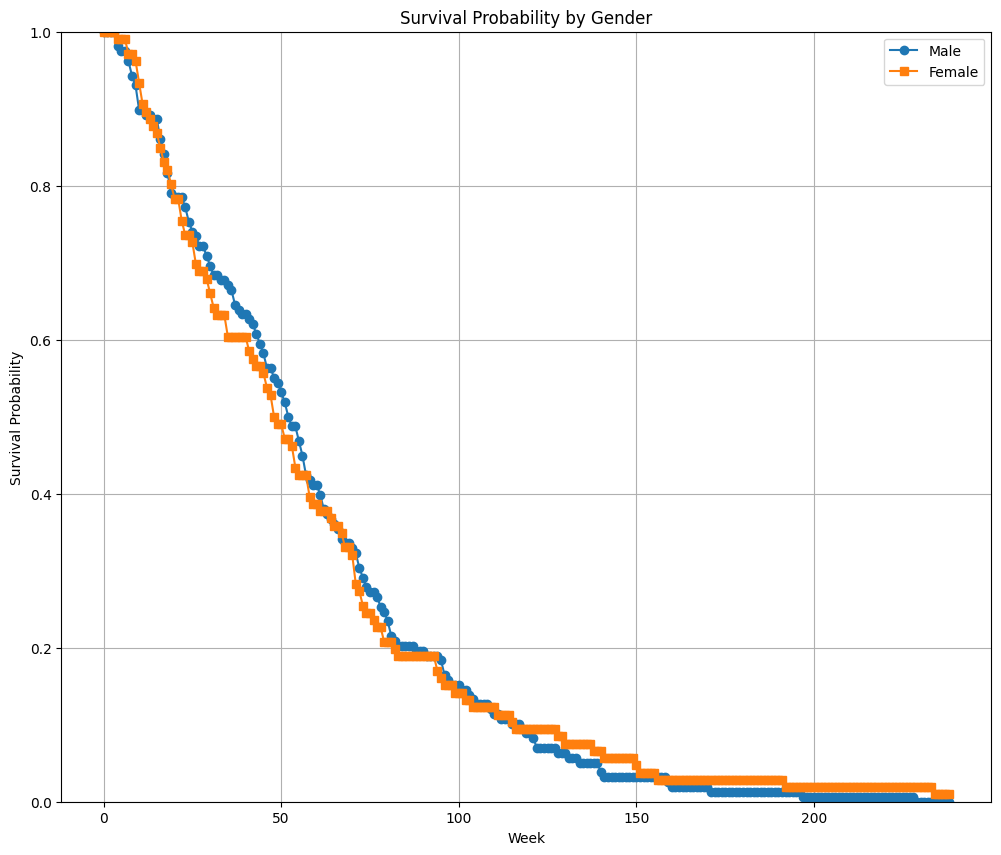

In [ ]:
# Plot male survival probability
plt.figure(figsize=(12,10))
plt.plot(survival_table['Week'], survival_table['Survival_Probability_Male'], marker='o', label='Male')

# Plot female survival probability
plt.plot(survival_table['Week'], survival_table['Survival_Probability_Female'], marker='s', label='Female')

# Labels and
plt.title('Survival Probability by Gender')
plt.xlabel('Week')
plt.ylabel('Survival Probability')
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=4d0be5a30a4b8e12ecbed6f5899ea8e104bc1dcb23340640c0fb83f309676e03
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


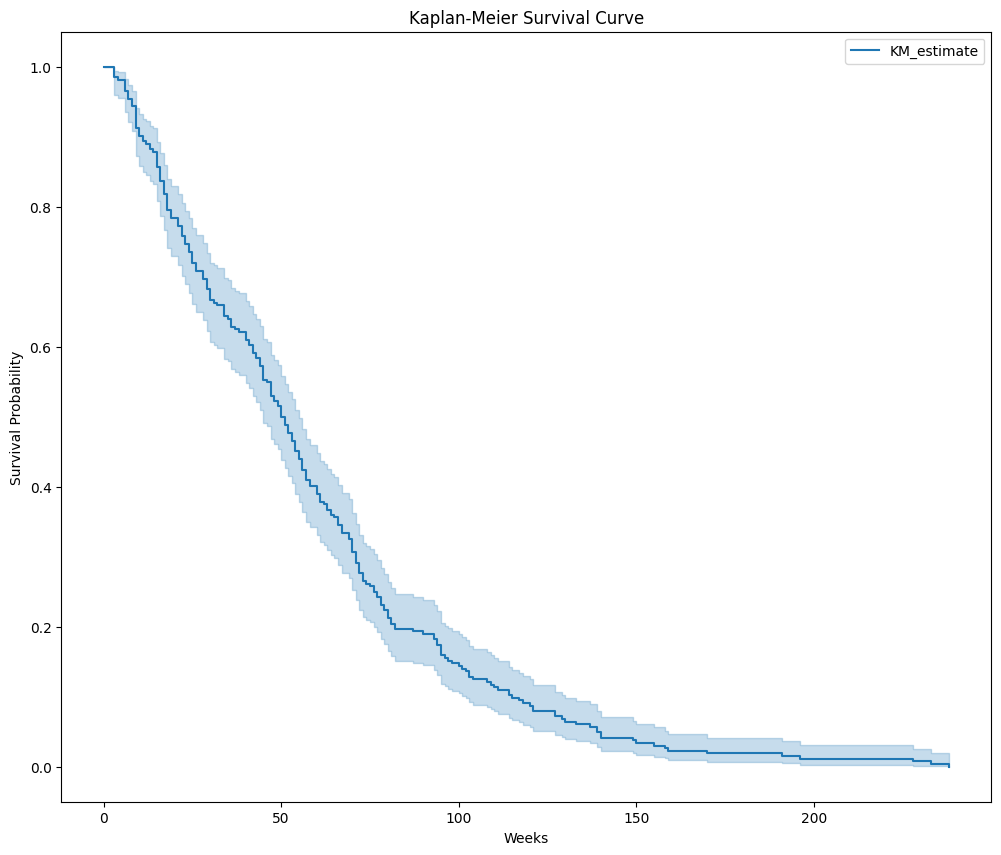

In [ ]:
from lifelines import KaplanMeierFitter

# survival_weeks = survival time
# event = 1 (death occurred), 0 (censored)

# Kaplan-Meier Model
kmf = KaplanMeierFitter()

# Create an 'event' column, assuming all patients are observed for the event (death)
df['event'] = 1

kmf.fit(
    durations=df["survival (weeks)"], # Corrected column name
    event_observed=df["event"]
)
plt.figure(figsize=(12,10))

kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Weeks")
plt.ylabel("Survival Probability")
plt.show()

          removed  observed  censored  entrance  at_risk
event_at                                                
0.0             0         0         0       264      264
3.0             4         4         0         0      264
4.0             1         1         0         0      260
6.0             4         4         0         0      259
7.0             3         3         0         0      255


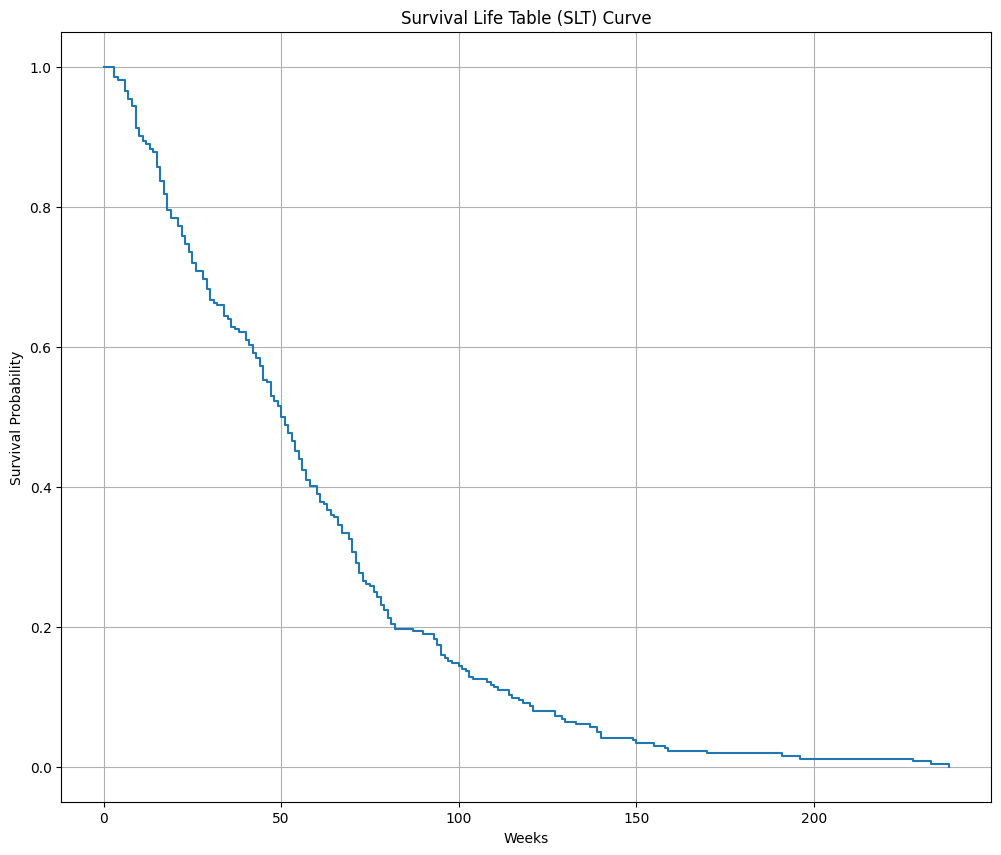

In [ ]:
# Access the life-table style event table from the fitted model
slt_table = kmf.event_table

print(slt_table.head())

# Calculate interval survival probability
slt_table["interval_survival"] = 1 - (slt_table["observed"] / slt_table["at_risk"])

# Cumulative survival probability
slt_table["cum_survival"] = slt_table["interval_survival"].cumprod()

# Plot SLT curve
plt.figure(figsize=(12,10))

plt.step(slt_table.index, slt_table["cum_survival"], where="post")

plt.title("Survival Life Table (SLT) Curve")
plt.xlabel("Weeks")
plt.ylabel("Survival Probability")

plt.grid(True)
plt.show()

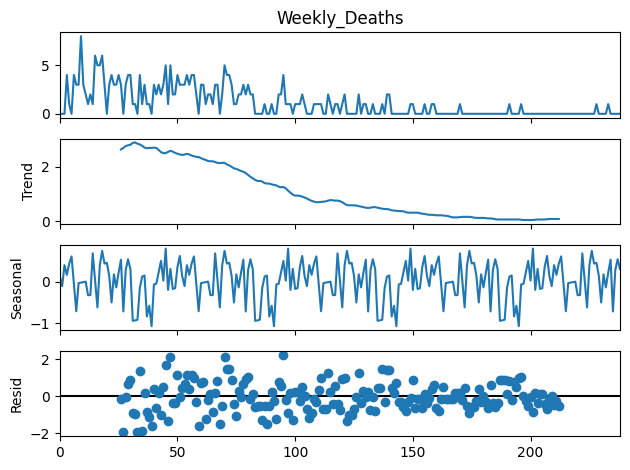

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Apply seasonal decomposition
# Using 'Weekly_Deaths' from the survival_table as the time series
result = seasonal_decompose(survival_table['Weekly_Deaths'], model='additive', period=52)

# Plot the decomposition
result.plot()
plt.show()

In [ ]:

# Import required class
from lifelines import CoxPHFitter

# Prepare dataset
# Rename columns to match expected names for the Cox model
df = df.rename(columns={
    'survival (weeks)': 'Survival_Week',
    'age_at_t0 (years)': 'Age',
    'who_performance_status': 'Performance',
    'delay_t0_to_radiotherapy (weeks)' : 'Radiotherapy Delay',
    'dose (Gy)' : 'Dose',
    'fractions_number' : 'Fractions'
})

# Calculate BMI: BMI = weight (kg) / (height (m))^2
df['BMI'] = df['weight (kg)'] / ((df['height (cm)'] / 100)**2)

# Event column: 1 means the patient died (all patients eventually die here)
df['Event'] = 1

# Convert Gender to numeric for Cox model (Male=0, Female=1)
df['Gender_num'] = df['gender'].map({'M':0, 'F':1})

# Drop rows with NaN in any of the required columns for the Cox model
df_cox = df[['Survival_Week','Event','Gender_num','Age','BMI','Performance','Radiotherapy Delay','Dose','Fractions']].dropna()

# Fit Cox proportional hazards model
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='Survival_Week', event_col='Event')

# Show model summary
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 194 total observations, 0 right-censored observations>
             duration col = 'Survival_Week'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 194
number of events observed = 194
   partial log-likelihood = -810.19
         time fit was run = 2026-03-31 11:02:14 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
Gender_num         -0.01      0.99      0.15           -0.30            0.29                0.74                1.34
Age                 0.01      1.01      0.01           -0.01            0.03                0.99                1.03
BMI                -0.03      0.97      0.02           -0.06            0.01                0.94                1.01
Performance         0.32      1.38      0.11            0.12            0.53                1.12                1.70
Radiotherapy Delay -0.26      0.77      0.10           -0.46           -0.06                0.63                0.94
Dose               -0.06      0.94      0.07           -0.21            0.08                0.81                1.09
Fractions           0.04      1.04      0.10           -0.15            0.23                0.86                1.26

                    cmp to     z      p  -log2(p)
covariate                                        
Gender_num            0.00 -0.04   0.97      0.05
Age                   0.00  0.95   0.34      1.56
BMI                   0.00 -1.54   0.12      3.01
Performance           0.00  3.07 <0.005      8.88
Radiotherapy Delay    0.00 -2.56   0.01      6.56
Dose                  0.00 -0.86   0.39      1.35
Fractions             0.00  0.41   0.68      0.55
---
Concordance = 0.67
Partial AIC = 1634.39
log-likelihood ratio test = 42.65 on 7 df
-log2(p) of ll-ratio test = 21.29

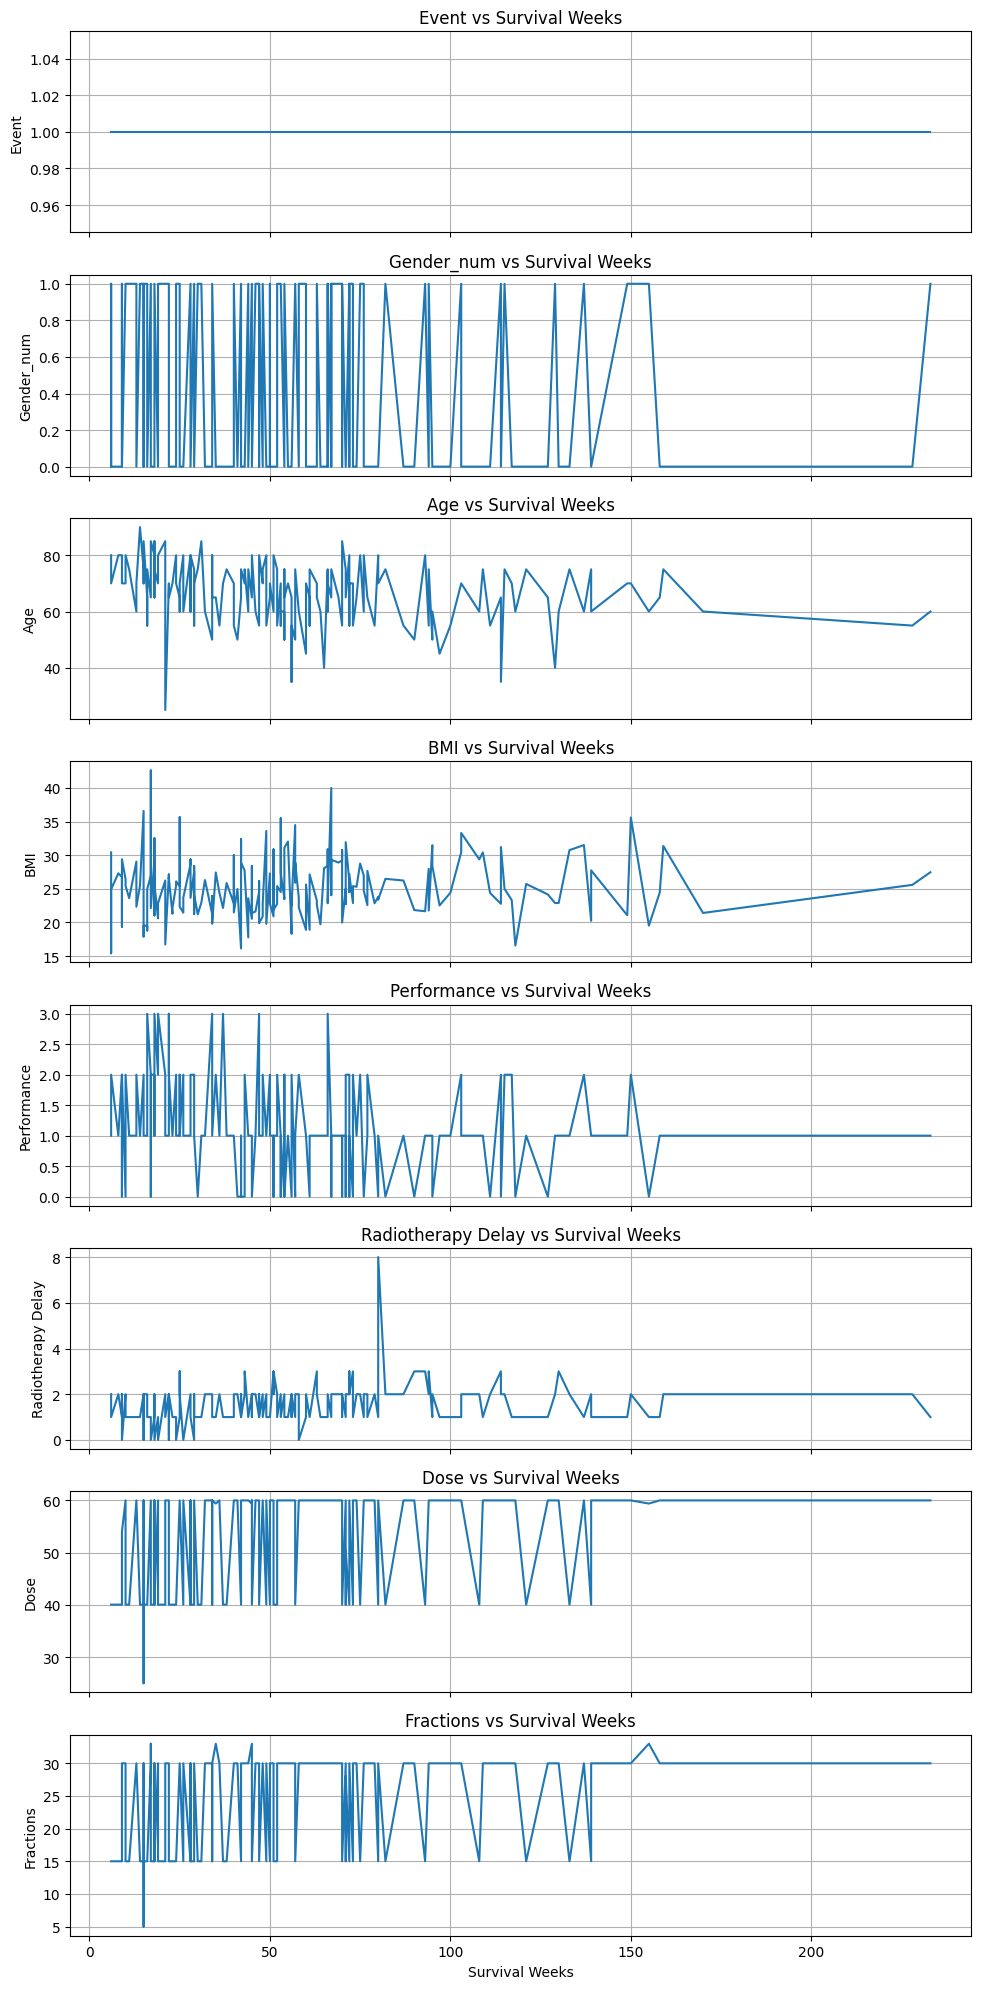

In [ ]:
# Sort data by Survival Week
df_plot = df_cox.sort_values(by='Survival_Week')

# Variables to plot
variables = ['Event','Gender_num','Age','BMI','Performance',
             'Radiotherapy Delay','Dose','Fractions']

# Create subplots (one for each variable)
n_vars = len(variables)
fig, axes = plt.subplots(n_vars, 1, figsize=(10, 2.5 * n_vars), sharex=True)

# If only one variable, axes won't be iterable
if n_vars == 1:
    axes = [axes]

# Plot each variable
for i, var in enumerate(variables):
    axes[i].plot(df_plot['Survival_Week'], df_plot[var])
    axes[i].set_ylabel(var)
    axes[i].set_title(f'{var} vs Survival Weeks')
    axes[i].grid(True)

# Common X label
plt.xlabel('Survival Weeks')

# Adjust layout
plt.tight_layout()

plt.show()

In [ ]:
# Significance level
alpha = 0.05

# Create a summary DataFrame
summary_df = cph.summary.copy()

# Add column for significance
summary_df['Significant'] = summary_df['p'] < alpha

# Optional: add interpretation
summary_df['Interpretation'] = summary_df.apply(
    lambda row: f"{row.name} increases risk" if row['coef']>0 and row['Significant']
    else (f"{row.name} decreases risk" if row['coef']<0 and row['Significant']
          else f"{row.name} not significant"), axis=1
)

summary_df[['coef','exp(coef)','p','Significant','Interpretation']]

,coef,exp(coef),p,Significant,Interpretation
covariate,,,,,
Gender_num,-0.006348,0.993672,0.966442,False,Gender_num not significant
Age,0.008848,1.008887,0.340189,False,Age not significant
BMI,-0.027933,0.972453,0.124365,False,BMI not significant
Performance,0.324958,1.383973,0.002125,True,Performance increases risk
Radiotherapy Delay,-0.262169,0.769381,0.010568,True,Radiotherapy Delay decreases risk
Dose,-0.063852,0.938144,0.392069,False,Dose not significant
Fractions,0.040480,1.041311,0.680944,False,Fractions not significant


In [ ]:

# Import required class
from lifelines import CoxPHFitter

# Prepare dataset
# Rename columns to match expected names for the Cox model
df = df.rename(columns={
    'survival (weeks)': 'Survival_Week',
    'age_at_t0 (years)': 'Age',
    'who_performance_status': 'Performance'
})

# Calculate BMI: BMI = weight (kg) / (height (m))^2
df['BMI'] = df['weight (kg)'] / ((df['height (cm)'] / 100)**2)

# Event column: 1 means the patient died (all patients eventually die here)
df['Event'] = 1

# Convert Gender to numeric for Cox model (Male=0, Female=1)
df['Gender_num'] = df['gender'].map({'M':0, 'F':1})

# Drop rows with NaN in any of the required columns for the Cox model
df_cox = df[['Survival_Week','Event','Gender_num','Age','BMI','Performance']].dropna()

# Fit Cox proportional hazards model
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='Survival_Week', event_col='Event')

# Show model summary
cph.print_summary()

In [ ]:
# Significance level
alpha = 0.05

# Create a summary DataFrame
summary_df = cph.summary.copy()

# Add column for significance
summary_df['Significant'] = summary_df['p'] < alpha

# Optional: add interpretation
summary_df['Interpretation'] = summary_df.apply(
    lambda row: f"{row.name} increases risk" if row['coef']>0 and row['Significant']
    else (f"{row.name} decreases risk" if row['coef']<0 and row['Significant']
          else f"{row.name} not significant"), axis=1
)

summary_df[['coef','exp(coef)','p','Significant','Interpretation']]

,coef,exp(coef),p,Significant,Interpretation
covariate,,,,,
Gender_num,-0.006348,0.993672,0.966442,False,Gender_num not significant
Age,0.008848,1.008887,0.340189,False,Age not significant
BMI,-0.027933,0.972453,0.124365,False,BMI not significant
Performance,0.324958,1.383973,0.002125,True,Performance increases risk
Radiotherapy Delay,-0.262169,0.769381,0.010568,True,Radiotherapy Delay decreases risk
Dose,-0.063852,0.938144,0.392069,False,Dose not significant
Fractions,0.040480,1.041311,0.680944,False,Fractions not significant


In [ ]:
# Use actual unique values from your dataset
genders = df['Gender_num'].unique()  # 0 and 1
performances = df['Performance'].unique()  # 0 to 3
ages = sorted(df['Age'].unique())  # all ages in dataset
bmis = sorted(df['BMI'].round(1).unique())  # rounded BMI for clarity

# Generate all realistic patient profiles
import itertools
all_combinations = list(itertools.product(genders, performances, ages, bmis))
patient_profiles = pd.DataFrame(all_combinations, columns=['Gender_num','Performance','Age','BMI'])

# Add label for plotting
def label_row(row):
    gender = 'M' if row['Gender_num']==0 else 'F'
    return f"{gender} Perf{row['Performance']} Age{row['Age']} BMI{row['BMI']}"

patient_profiles['Label'] = patient_profiles.apply(label_row, axis=1)

print(f"Total realistic patient profiles: {len(patient_profiles)}")

Total realistic patient profiles: 17500


In [ ]:
# Re-fit the Cox proportional hazards model (cph) with only the desired covariates
# This step ensures that the model's expected input columns match patient_profiles
# We assume 'df' has been updated with BMI, Event, Gender_num from previous cells
temp_df_for_cph_prediction = df[['Survival_Week','Event','Gender_num','Age','BMI','Performance']].dropna()

# Re-initialize and fit cph with the correct subset of covariates for prediction
cph = CoxPHFitter()
cph.fit(temp_df_for_cph_prediction, duration_col='Survival_Week', event_col='Event')

# Now predict partial hazard (relative hazard) for each patient profile
patient_profiles['Predicted_Hazard'] = cph.predict_partial_hazard(patient_profiles[['Gender_num','Performance','Age','BMI']])

In [ ]:
patient_profiles = patient_profiles.sort_values(by='Predicted_Hazard', ascending=False)

In [ ]:
import itertools

# Define ranges
genders = [0, 1]  # 0=Male, 1=Female
performances = [0,1,2,3]
ages = [40,50,60]
bmis = [22,25,28]

# Generate all combinations
all_combinations = list(itertools.product(genders, performances, ages, bmis))

# Create DataFrame
patient_profiles = pd.DataFrame(all_combinations, columns=['Gender_num','Performance','Age','BMI'])

# Add label for plotting
def label_row(row):
    gender = 'M' if row['Gender_num']==0 else 'F'
    return f"{gender} Perf{row['Performance']} Age{row['Age']} BMI{row['BMI']}"

patient_profiles['Label'] = patient_profiles.apply(label_row, axis=1)

print(f"Total patient profiles: {len(patient_profiles)}")  # Should be 2*4*3*3 = 72

Total patient profiles: 72


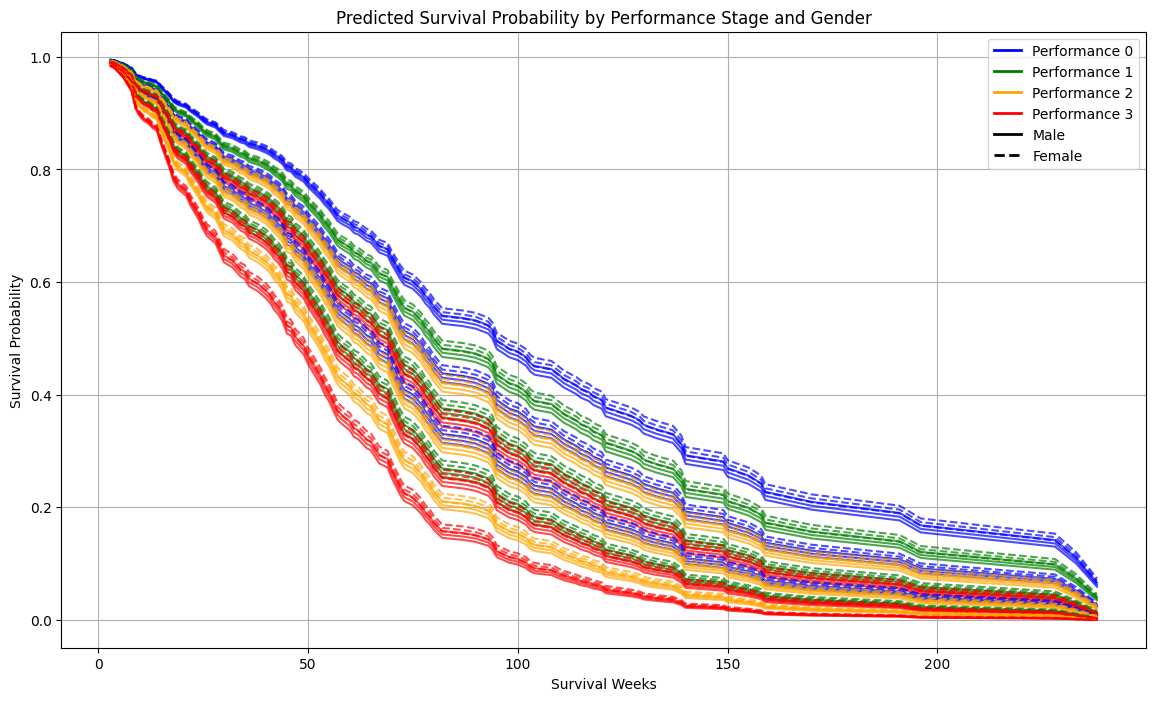

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(14,8))

# Define colors for Performance stage
performance_colors = {0:'blue', 1:'green', 2:'orange', 3:'red'}

# Define line style for Gender
gender_styles = {0:'-', 1:'--'}  # Male solid, Female dashed

# Plot survival curves
for i in range(len(patient_profiles)):
    row = patient_profiles.iloc[i:i+1]
    survival_func = cph.predict_survival_function(row)

    perf = row['Performance'].values[0]
    gender = row['Gender_num'].values[0]

    plt.plot(
        survival_func.index,
        survival_func.values.flatten(),
        color=performance_colors[perf],
        linestyle=gender_styles[gender],
        alpha=0.7
    )

# Create legend for Performance
from matplotlib.lines import Line2D
legend_perf = [Line2D([0], [0], color=c, lw=2, label=f'Performance {p}')
               for p,c in performance_colors.items()]
# Legend for Gender
legend_gender = [Line2D([0], [0], color='black', lw=2, linestyle=s, label=g)
                 for g,s in zip(['Male','Female'], ['-', '--'])]

plt.legend(handles=legend_perf + legend_gender, loc='upper right')
plt.title('Predicted Survival Probability by Performance Stage and Gender')
plt.xlabel('Survival Weeks')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

In [ ]:
# Example: only Performance 0 & 3 and Age=50, BMI=25
filtered_profiles = patient_profiles[
    ((patient_profiles['Performance']==0) | (patient_profiles['Performance']==3)) &
    (patient_profiles['Age']==50) &
    (patient_profiles['BMI']==25)
]

plt.figure(figsize=(10,6))
for i in range(len(filtered_profiles)):
    sf = cph.predict_survival_function(filtered_profiles.iloc[i:i+1])
    plt.plot(sf.index, sf.values.flatten(), label=filtered_profiles['Label'].iloc[i])

plt.title('Survival Curves: Performance 0 vs 3, Age 50, BMI 25')
plt.xlabel('Survival Weeks')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.show()

# **RIDDHIMA**


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Radiotherapy Delay' failed the non-proportional test: p-value is 0.0062.

   Advice 1: the functional form of the variable 'Radiotherapy Delay' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'Radiotherapy Delay' using pd.cut, and then specify it in
`strata=['Radiotherapy Delay', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assump

[[<Axes: xlabel='rank-transformed time\n(p=0.9701)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9553)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3230)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3295)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6364)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6251)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1118)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1062)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0062)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0063)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1233)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1339)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1841)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1982)'>]]

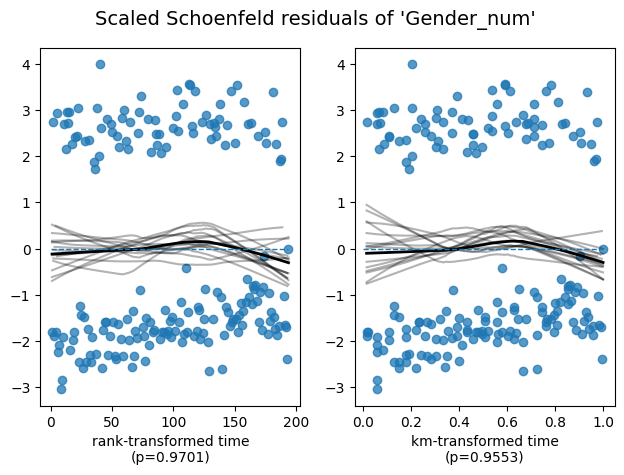

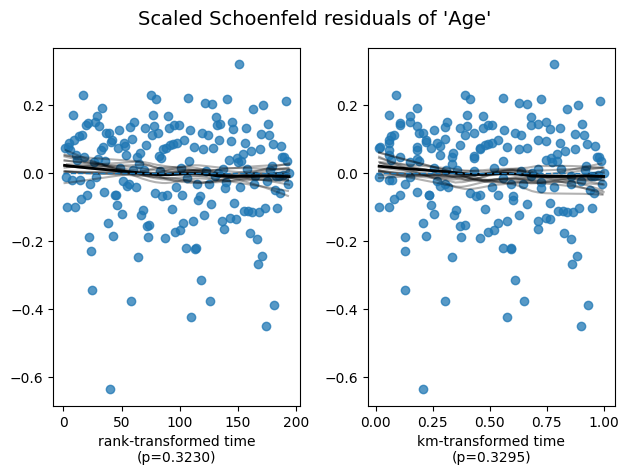

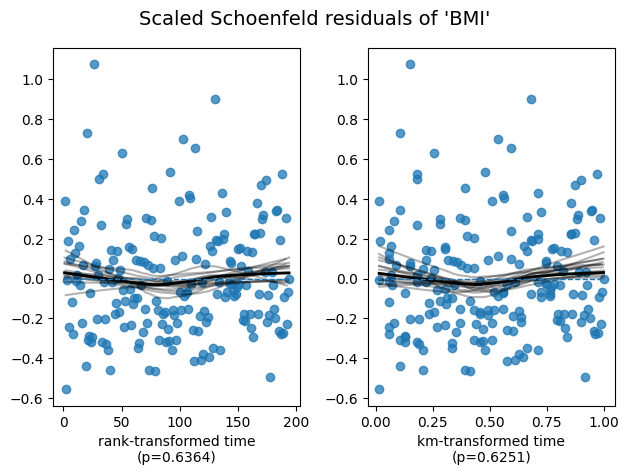

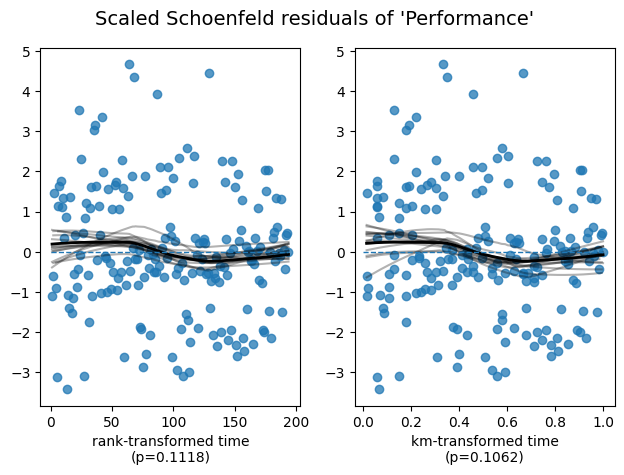

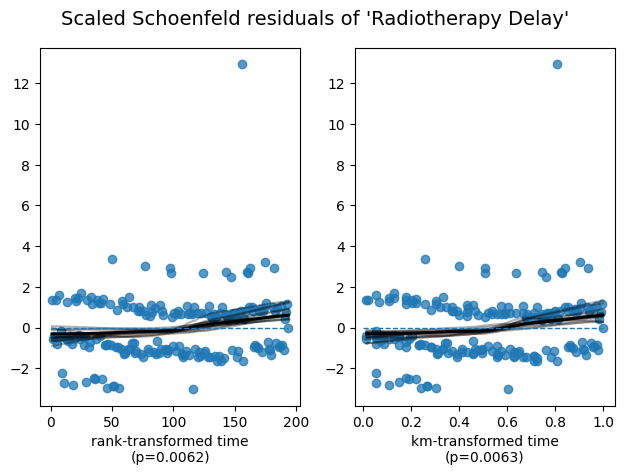

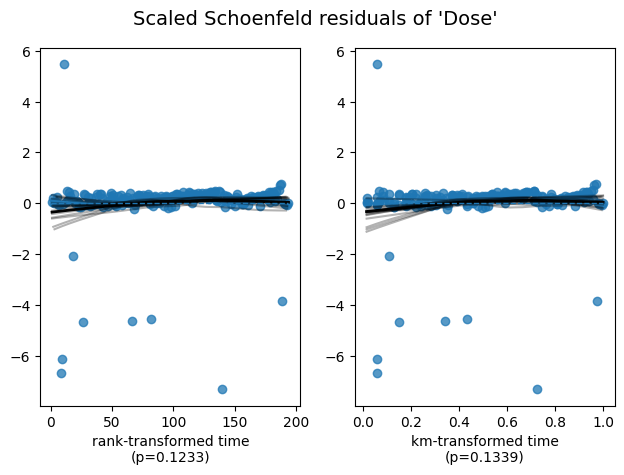

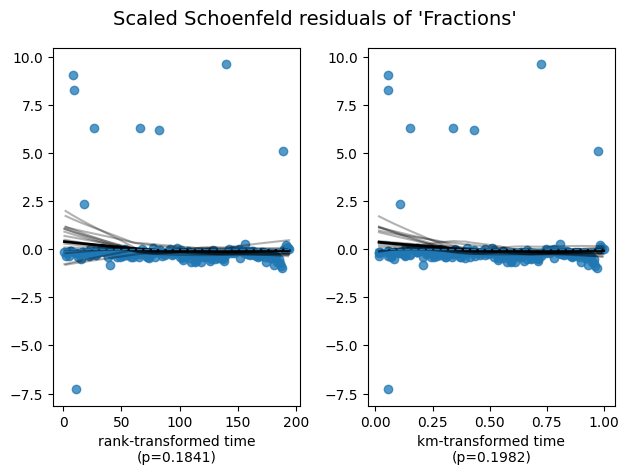

In [ ]:
cph.check_assumptions(df_cox, p_value_threshold=0.05, show_plots=True)

In [ ]:
import numpy as np

# Create log(time)
df_cox['log_time'] = np.log(df_cox['Survival_Week'])

# Create interaction term for radiotherapy delay
df_cox['radiotherapy_delay_time'] = df_cox['Radiotherapy Delay'] * df_cox['log_time']

# Refit model
cph_td = CoxPHFitter()
cph_td.fit(df_cox[['Survival_Week','Event',
                   'Radiotherapy Delay',
                   'radiotherapy_delay_time',
                   'Age','BMI','Performance','Gender_num']],
           duration_col='Survival_Week',
           event_col='Event')

cph_td.print_summary()

<lifelines.CoxPHFitter: fitted with 194 total observations, 0 right-censored observations>
             duration col = 'Survival_Week'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 194
number of events observed = 194
   partial log-likelihood = -745.30
         time fit was run = 2026-03-31 12:07:32 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
Radiotherapy Delay       2.49     12.07      0.44            1.62            3.36                5.05               28.84
radiotherapy_delay_time -0.59      0.56      0.10           -0.79           -0.39                0.46                0.68
Age                      0.00      1.00      0.01           -0.01            0.02                0.99                1.02
BMI                     -0.01      0.99      0.02           -0.04            0.03                0.96                1.03
Performance              0.09      1.10      0.11           -0.12            0.30                0.89                1.35
Gender_num              -0.03      0.97      0.15           -0.33            0.26                0.72                1.30

                         cmp to     z      p  -log2(p)
covariate                                             
Radiotherapy Delay         0.00  5.61 <0.005     25.53
radiotherapy_delay_time    0.00 -5.75 <0.005     26.76
Age                        0.00  0.47   0.64      0.65
BMI                        0.00 -0.38   0.70      0.51
Performance                0.00  0.85   0.39      1.35
Gender_num                 0.00 -0.23   0.82      0.29
---
Concordance = 0.88
Partial AIC = 1502.59
log-likelihood ratio test = 172.44 on 6 df
-log2(p) of ll-ratio test = 112.50

In [ ]:
import statsmodels.api as sm

# Make sure delay variable exists (rename if needed)
df = df.rename(columns={
    'Radiotherapy Delay': 'Delay'   # change to your actual column name
})

# Select relevant columns and drop missing values
df_reg = df[['Survival_Week', 'Performance', 'Delay']].dropna()

# Define X and y
X = df_reg[['Performance', 'Delay']]
y = df_reg['Survival_Week']

# Add intercept (β0)
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Survival_Week   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     8.556
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           0.000276
Time:                        13:04:26   Log-Likelihood:                -985.64
No. Observations:                 194   AIC:                             1977.
Df Residuals:                     191   BIC:                             1987.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          57.4494      7.842      7.326      

In [ ]:
# Predicted survival
df_reg['Predicted_Survival'] = model.predict(X)

# Residuals (Detrended series)
df_reg['Residuals'] = df_reg['Survival_Week'] - df_reg['Predicted_Survival']

In [ ]:
residual_series = df_reg['Residuals']

In [ ]:
df_reg = df_reg.sort_values(by='Survival_Week')

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(residual_series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 3.276412867606589
p-value: 1.0


In [ ]:
df_reg['Residuals_diff'] = df_reg['Residuals'].diff().dropna()


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_reg['Residuals_diff'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -10.392589164163809
p-value: 2.0029748405315126e-18


In [ ]:
df_reg = df_reg.sort_values(by='Survival_Week')
df_reg.reset_index(drop=True, inplace=True)

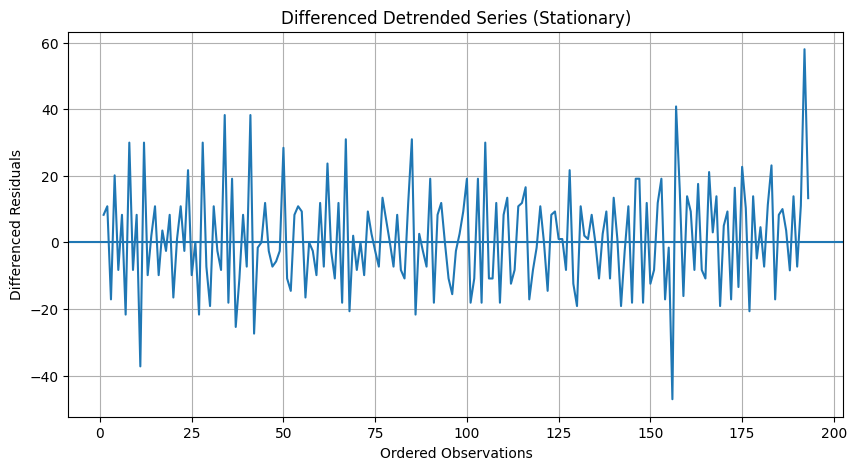

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df_reg.index[1:], df_reg['Residuals_diff'].dropna())

plt.title("Differenced Detrended Series (Stationary)")
plt.xlabel("Ordered Observations")
plt.ylabel("Differenced Residuals")

plt.axhline(y=0)
plt.grid()

plt.show()

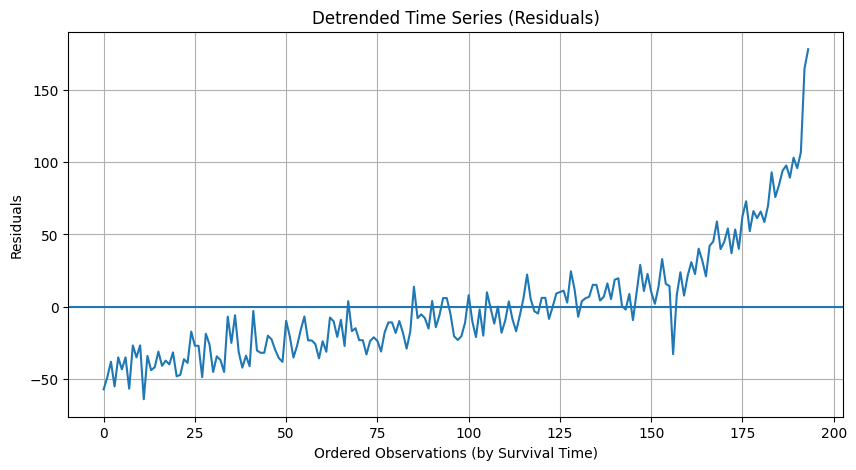

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_reg.index, df_reg['Residuals'])

plt.title("Detrended Time Series (Residuals)")
plt.xlabel("Ordered Observations (by Survival Time)")
plt.ylabel("Residuals")

plt.axhline(y=0)  # reference line
plt.grid()

plt.show()

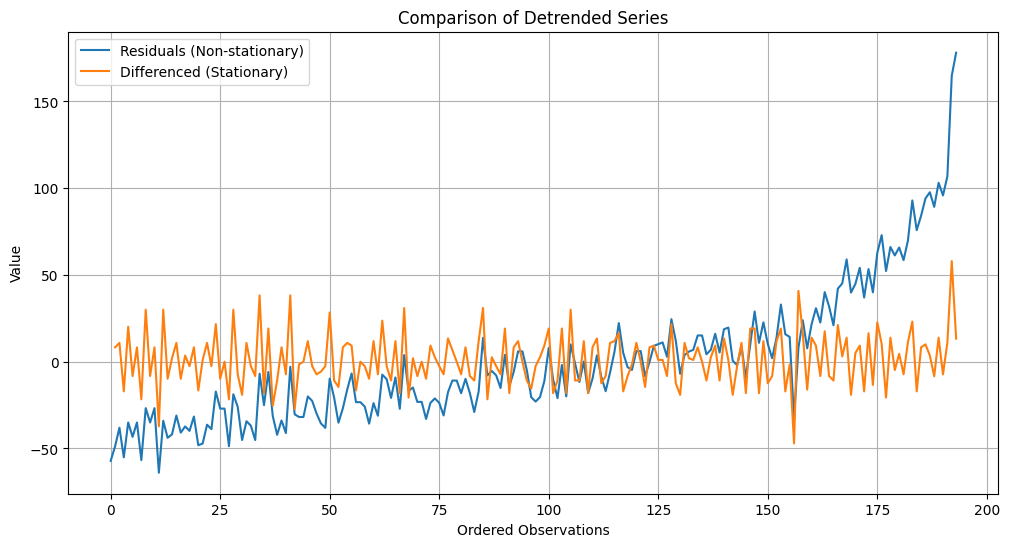

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df_reg['Residuals'], label='Residuals (Non-stationary)')
plt.plot(df_reg['Residuals_diff'], label='Differenced (Stationary)')

plt.title("Comparison of Detrended Series")
plt.xlabel("Ordered Observations")
plt.ylabel("Value")

plt.legend()
plt.grid()

plt.show()

In [ ]:
series = df_reg['Residuals_diff'].dropna()

<Figure size 1000x500 with 0 Axes>

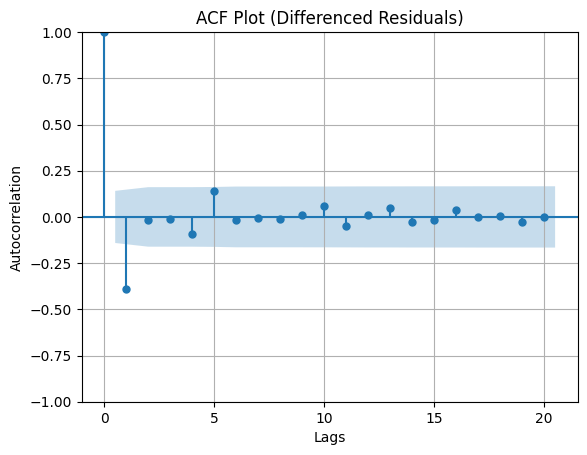

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))
plot_acf(series, lags=20)

plt.title("ACF Plot (Differenced Residuals)")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")

plt.grid()
plt.show()

<Figure size 1000x500 with 0 Axes>

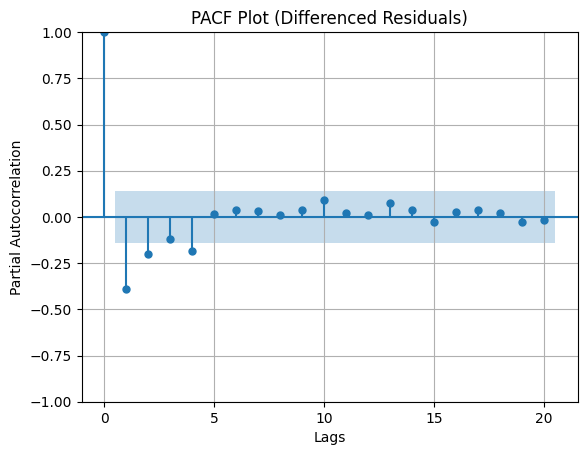

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,5))
plot_pacf(series, lags=20, method='ywm')

plt.title("PACF Plot (Differenced Residuals)")
plt.xlabel("Lags")
plt.ylabel("Partial Autocorrelation")

plt.grid()
plt.show()

In [ ]:
import numpy as np
from statsmodels.tsa.stattools import acf, pacf

lag_acf = acf(series, nlags=20)
lag_pacf = pacf(series, nlags=20)

conf = 1.96 / np.sqrt(len(series))

# Find q (ACF cutoff)
q = 0
for i in range(1, len(lag_acf)):
    if abs(lag_acf[i]) < conf:
        q = i - 1
        break

# Find p (PACF cutoff)
p = 0
for i in range(1, len(lag_pacf)):
    if abs(lag_pacf[i]) < conf:
        p = i - 1
        break

print("Suggested p:", p)
print("Suggested q:", q)

Suggested p: 2
Suggested q: 1


# **ARUNIMA**

In [123]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

FOR STANDALONE MODELS AR1, AR2, MA1, MA2

In [124]:
models = {
    "AR1": (1,0,0),
    "AR2": (2,0,0),
    "MA1": (0,0,1),
    "MA2": (0,0,2),
    }

results = []

for name, order in models.items():

    model = ARIMA(df_reg['Residuals_diff'], order=order)
    result = model.fit()

    aic = result.aic
    bic = result.bic

    # Define n and k for AICc and BICc calculations for the current model
    n = result.nobs
    k = len(result.params)

    # AICc formula
    aicc = aic + (2*k*(k+1))/(n-k-1)
    # BICc formula
    bicc = bic + (2*k*(k+1))/(n-k-1)


    results.append([name, aic, aicc, bic, bicc])

comparison_table_1 = pd.DataFrame(results, columns=["Model","AIC","AICc","BIC","BICc"])

print(comparison_table_1)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

  Model          AIC         AICc          BIC         BICc
0   AR1  1574.419259  1574.545575  1584.222833  1584.349149
1   AR2  1566.991899  1567.203539  1580.063332  1580.274972
2   MA1  1555.545262  1555.671578  1565.348836  1565.475152
3   MA2  1556.234656  1556.446296  1569.306088  1569.517729


In [125]:
# Best model by AICc
best_aicc_model = comparison_table_1.loc[comparison_table_1["AICc"].idxmin()]

# Best model by BICc
best_bicc_model = comparison_table_1.loc[comparison_table_1["BICc"].idxmin()]

print("Best model based on AICc")
print(best_aicc_model)

print("\nBest model based on BICc")
print(best_bicc_model)

Best model based on AICc
Model            MA1
AIC      1555.545262
AICc     1555.671578
BIC      1565.348836
BICc     1565.475152
Name: 2, dtype: object

Best model based on BICc
Model            MA1
AIC      1555.545262
AICc     1555.671578
BIC      1565.348836
BICc     1565.475152
Name: 2, dtype: object


FOR ARIMA

In [126]:
import pandas as pd
import itertools
from statsmodels.tsa.arima.model import ARIMA

series_1 = df_reg['Residuals']

p = range(1,3)
d = range(1,3)
q = range(1,3)

orders = list(itertools.product(p,d,q))

results = []

for order in orders:

    try:
        model = ARIMA(series_1, order=order)
        res = model.fit()

        aic = res.aic
        bic = res.bic

        n = res.nobs
        k = len(res.params)

        # AICc formula
        aicc = aic + (2*k*(k+1))/(n-k-1)

        # BICc formula
        bicc = bic + (2*k*(k+1))/(n-k-1)

        results.append([order,aic,aicc,bic,bicc])

    except:
        continue

comparison_table = pd.DataFrame(
    results,
    columns=["Order(p,d,q)","AIC","AICc","BIC","BICc"]
)

comparison_table_2 = comparison_table.sort_values("AICc")

print(comparison_table_2)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

  Order(p,d,q)          AIC         AICc          BIC         BICc
3    (1, 2, 2)  1541.892384  1542.104025  1554.922366  1555.134006
7    (2, 2, 2)  1543.847494  1544.166643  1560.134971  1560.454120
5    (2, 1, 2)  1548.940491  1549.259640  1565.253942  1565.573091
0    (1, 1, 1)  1561.850535  1561.976851  1571.638606  1571.764922
1    (1, 1, 2)  1563.373622  1563.585263  1576.424383  1576.636023
4    (2, 1, 1)  1563.497599  1563.709240  1576.548360  1576.760000
6    (2, 2, 1)  1565.140982  1565.352622  1578.170963  1578.382603
2    (1, 2, 1)  1572.932312  1573.058628  1582.704798  1582.831114


In [127]:
# Best model by AICc
best_aicc_model = comparison_table_2.loc[comparison_table["AICc"].idxmin()]

# Best model by BICc
best_bicc_model = comparison_table_2.loc[comparison_table["BICc"].idxmin()]

print("Best model based on AICc")
print(best_aicc_model)

print("\nBest model based on BICc")
print(best_bicc_model)

Best model based on AICc
Order(p,d,q)      (1, 2, 2)
AIC             1541.892384
AICc            1542.104025
BIC             1554.922366
BICc            1555.134006
Name: 3, dtype: object

Best model based on BICc
Order(p,d,q)      (1, 2, 2)
AIC             1541.892384
AICc            1542.104025
BIC             1554.922366
BICc            1555.134006
Name: 3, dtype: object
